<a href="https://colab.research.google.com/github/Dhruv0830/Python/blob/main/NLP_Practise.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"dhruvbakshi30","key":"cbdf7ac7a4155a8c2256b3a692d41a6e"}'}

In [ ]:
!mkdir kaggle
!cp kaggle.json kaggle/
!chmod 600 kaggle/kaggle.json
!kaggle datasets download -d lakshmi25npathi/imdb-dataset-of-50k-movie-reviews

Dataset URL: https://www.kaggle.com/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews
License(s): other
100% 25.7M/25.7M [00:00<00:00, 140MB/s] 



In [ ]:
!unzip imdb-dataset-of-50k-movie-reviews.zip -d kaggle/

Archive:  imdb-dataset-of-50k-movie-reviews.zip
  inflating: kaggle/IMDB Dataset.csv  


In [ ]:
#Imports
import pandas as pd
import numpy as np

In [ ]:
#Reading the data
data = pd.read_csv('kaggle/IMDB Dataset.csv')
data.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [ ]:
# Problem 1

# Apply all the preprocessing techniques that you think are necessary
data['review'] = data['review'].str.replace(r'<[^>]*>', '', regex=True)
data['review'] = data['review'].str.replace(r'[^a-zA-Z\s]', '', regex=True)
data['review'] = data['review'].str.lower()
data.head()



,review,sentiment
0,one of the other reviewers has mentioned that ...,positive
1,a wonderful little production the filming tech...,positive
2,i thought this was a wonderful way to spend ti...,positive
3,basically theres a family where a little boy j...,negative
4,petter matteis love in the time of money is a ...,positive


In [ ]:
#stop word removal
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))
data['review'] = data['review'].apply(lambda x: ' '.join([word for word in x.split() if word not in (stop_words)]))
data.head()

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


,review,sentiment
0,one reviewers mentioned watching oz episode yo...,positive
1,wonderful little production filming technique ...,positive
2,thought wonderful way spend time hot summer we...,positive
3,basically theres family little boy jake thinks...,negative
4,petter matteis love time money visually stunni...,positive


In [ ]:
data['review'][0]

'one reviewers mentioned watching oz episode youll hooked right exactly happened methe first thing struck oz brutality unflinching scenes violence set right word go trust show faint hearted timid show pulls punches regards drugs sex violence hardcore classic use wordit called oz nickname given oswald maximum security state penitentary focuses mainly emerald city experimental section prison cells glass fronts face inwards privacy high agenda em city home manyaryans muslims gangstas latinos christians italians irish moreso scuffles death stares dodgy dealings shady agreements never far awayi would say main appeal show due fact goes shows wouldnt dare forget pretty pictures painted mainstream audiences forget charm forget romanceoz doesnt mess around first episode ever saw struck nasty surreal couldnt say ready watched developed taste oz got accustomed high levels graphic violence violence injustice crooked guards wholl sold nickel inmates wholl kill order get away well mannered middle cl

In [ ]:
# Problem 2
total_words = 0
data['total_words'] = data['review'].str.split().apply(len)
# data['unique_words'] = data['review'].str.split().apply(set).apply(len)

# unique_words = data['unique_words'].sum()
total_words = data['total_words'].sum()
vocab = data['review'].str.split().explode().nunique()
print(f"The total number of words in the entire corpus is {total_words}")
print(f"The total number of unique words in the entire corpus is {vocab}")
# print(f"The total number of unique words in the entire corpus is {unique_words}")

# Find out the number of words in the entire corpus and also the total number of unique words(vocabulary) using just python

The total number of words in the entire corpus is 5930080
The total number of unique words in the entire corpus is 214478


In [ ]:
vocab_words = data['review'].str.split().explode().value_counts()
vocab = pd.DataFrame(vocab_words)
vocab


,count
review,
movie,83578
film,74514
one,50392
like,38834
good,28502
...,...
directorthats,1
tablecloths,1
englishexcept,1


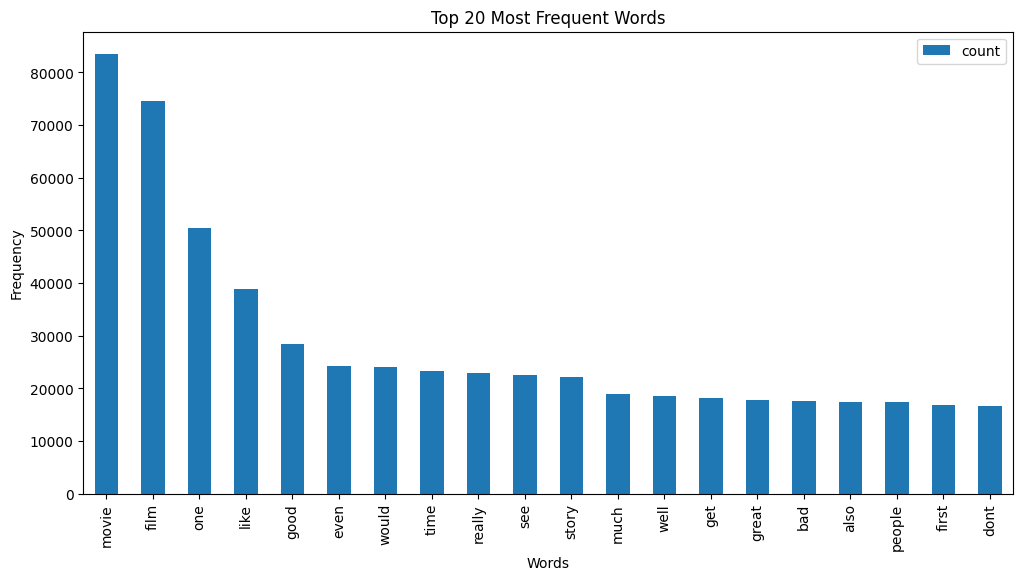

In [ ]:
# Plotting the top 20 words so the labels are actually readable
import matplotlib.pyplot as plt
vocab.head(20).plot(kind='bar', figsize=(12, 6))
plt.title('Top 20 Most Frequent Words')
plt.ylabel('Frequency')
plt.xlabel('Words')
plt.show()

In [ ]:
from re import X
# Problem 3

# Apply One Hot Encoding
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(data['review'], data['sentiment'], test_size=0.2, random_state=42)

# Create an instance of the OneHotEncoder
encoder = OneHotEncoder(handle_unknown='ignore')
encoded_train_data = encoder.fit_transform(X_train.reset_index())

encoded_test_data = encoder.transform(X_test.reset_index())

labels = LabelEncoder()
y_train = labels.fit_transform(y_train)
y_test = labels.transform(y_test)


# df = pd.DataFrame(encoded_data)
# df
# encoded_data[0]

In [ ]:
labels.classes_

array(['negative', 'positive'], dtype=object)

In [ ]:
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.ensemble import RandomForestClassifier

model2 = RandomForestClassifier(criterion='gini', n_estimators= 10)
# model = SGDClassifier(loss = 'log_loss')

model2.fit(encoded_train_data, y_train)

y_pred = model2.predict(encoded_test_data)

accuracy = accuracy_score(y_test, y_pred)


In [ ]:
print(f"Accuracy", accuracy)
print(f"Precision", precision_score(y_test, y_pred))
print(f"Recall", recall_score(y_test, y_pred))
print(f"F1 Score", f1_score(y_test, y_pred))

Accuracy 0.4971
Precision 1.0
Recall 0.0019845207382417148
F1 Score 0.003961180431768667


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.50      1.00      0.66      4961
           1       1.00      0.00      0.00      5039

    accuracy                           0.50     10000
   macro avg       0.75      0.50      0.33     10000
weighted avg       0.75      0.50      0.33     10000



In [ ]:
# Problem 4
from sklearn.feature_extraction.text import CountVectorizer

cv = CountVectorizer(ngram_range=(1,2))
encoded_data = cv.fit_transform(X_train)
encoded_data_test = cv.transform(X_test)


# Apply bag words and find the vocabulary also find the times each word has occured

In [ ]:
model_bow = RandomForestClassifier(criterion='gini', n_estimators= 10)
model_bow.fit(encoded_data, y_train)

y_pred = model_bow.predict(encoded_data_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy", accuracy)
print(f"Precision", precision_score(y_test, y_pred))
print(f"Recall", recall_score(y_test, y_pred))
print(f"F1 Score", f1_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

Accuracy 0.7638
Precision 0.7969824717106723
Recall 0.7128398491764238
F1 Score 0.7525665200083804
              precision    recall  f1-score   support

           0       0.74      0.82      0.77      4961
           1       0.80      0.71      0.75      5039

    accuracy                           0.76     10000
   macro avg       0.77      0.76      0.76     10000
weighted avg       0.77      0.76      0.76     10000

[[4046  915]
 [1447 3592]]


In [ ]:
vocab_1 = cv.get_feature_names_out()
print(f"Total vocabulary size: {len(vocab_1)}")
print(f"First 10 words: {vocab_1[:10]}")

Total vocabulary size: 2903440
First 10 words: ['aa' 'aa acting' 'aa antics' 'aa cultrehab' 'aa group' 'aa jaega'
 'aa level' 'aa meetings' 'aa meri' 'aa milnes']


In [ ]:
# Problem 5

# Apply bag of bi-gram and bag of tri-gram and write down your observation about the dimensionality of the vocabulary

In [ ]:
# Problem 6
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf = TfidfVectorizer()
encoded_data = tfidf.fit_transform(X_train)
encoded_data_test = tfidf.transform(X_test)

# Apply tf-idf and find out the idf scores of words, also find out the vocabulary.

In [ ]:
vocab_df = pd.DataFrame(tfidf.get_feature_names_out())

In [ ]:
total_tfidf_scores = encoded_data.sum(axis=0).A1

# 2. Build your vocabulary DataFrame with both the Word and its Score
vocab_df = pd.DataFrame({
    'Feature': tfidf.get_feature_names_out(),
    'Total_Score': total_tfidf_scores
})

# 3. Sort by the highest score to find the top features
# Change ascending=True if you want to see the rarest words instead!
vocab_df = vocab_df.sort_values(by='Total_Score', ascending=False)

# View the top 10 most hea

In [ ]:
vocab_df

,Feature,Total_Score
107031,movie,1741.470166
57990,film,1429.446178
115856,one,955.385063
93746,like,832.201604
67299,good,734.767887
...,...,...
170198,turnbuckles,0.017793
165745,tiltawhirl,0.017793
161071,tannouncement,0.017793
27957,chokeslammed,0.017793


In [ ]:
#data attribute to get the tfidf values in the sparse array
encoded_data[0].data

array([0.07259616, 0.05319722, 0.06615485, 0.0908479 , 0.06634733,
       0.06641221, 0.07897653, 0.08363719, 0.05433534, 0.07977087,
       0.10488264, 0.0391576 , 0.08294161, 0.02770699, 0.0547211 ,
       0.02952402, 0.0764816 , 0.02984748, 0.03108652, 0.05870956,
       0.06786569, 0.0585102 , 0.0470708 , 0.04918313, 0.05601483,
       0.04599647, 0.10915292, 0.07289977, 0.07192892, 0.11386147,
       0.07744988, 0.07161923, 0.07651369, 0.02657636, 0.03152646,
       0.07235513, 0.04070293, 0.1079294 , 0.11260212, 0.07869212,
       0.10302503, 0.02564676, 0.03705197, 0.09728878, 0.02868371,
       0.04396458, 0.03748027, 0.04168142, 0.12661934, 0.11857002,
       0.08813265, 0.09126418, 0.0308818 , 0.04715104, 0.11597872,
       0.12191079, 0.06354448, 0.09338143, 0.05261773, 0.04538485,
       0.04589598, 0.02783187, 0.03080879, 0.02986005, 0.04690591,
       0.09273611, 0.04766387, 0.08407545, 0.0447483 , 0.09479075,
       0.06602828, 0.1079294 , 0.12661934, 0.12661934, 0.09447

In [ ]:
non_zero_indices = encoded_data[0].indices
non_zero_values = encoded_data[0].data
feature_names = tfidf.get_feature_names_out()

first_review = {feature_names[index]: score for index, score in zip(non_zero_indices, non_zero_values)}
first_review

{'thats': np.float64(0.07259616166185279),
 'kept': np.float64(0.053197215286932276),
 'asking': np.float64(0.06615485271166373),
 'many': np.float64(0.09084789919997958),
 'fights': np.float64(0.06634733298405704),
 'screaming': np.float64(0.06641220863084853),
 'matches': np.float64(0.07897652551425759),
 'swearing': np.float64(0.0836371869279455),
 'general': np.float64(0.054335340013196044),
 'mayhem': np.float64(0.07977086658395624),
 'permeate': np.float64(0.1048826385659475),
 'minutes': np.float64(0.03915759752669115),
 'comparisons': np.float64(0.0829416071459161),
 'also': np.float64(0.027706991915859572),
 'stand': np.float64(0.054721102155570585),
 'think': np.float64(0.029524022353603876),
 'onedimensional': np.float64(0.07648159563184725),
 'characters': np.float64(0.02984747875860985),
 'little': np.float64(0.031086518725075542),
 'depth': np.float64(0.058709564859452876),
 'virtually': np.float64(0.06786569198435508),
 'impossible': np.float64(0.05851020012481572),
 'ca